# Evaluating Model Performance

In [2]:
# IMPORT LIBRARIES AND CONFIGURE PATHS
# Core scientific computing libraries for data analysis
import numpy as np          # Numerical operations and array handling
import scipy as sc          # Scientific computing functions (filtering, etc.)
import pandas as pd         # Data manipulation and analysis

# Visualization library
import matplotlib.pyplot as plt  # Plotting and figure generation
import seaborn as sns

# System and file handling utilities
from os.path import join as ospj  # Cross-platform path joining
# from utils import *               # Custom utility functions

# Load configuration paths and settings
from config import Config
# Extract key paths: raw data, processed data, metadata, figures, and patient IDs
datapath, prodatapath, metapath, figpath, rid_hup = Config.deal(['datapath','prodatapath','metapath','figpath','rid_hup'])

## NDD heritage

In [3]:
ndd_old = pd.read_csv(ospj(prodatapath,'res_series_list_ndd.csv'))

<Axes: xlabel='hidden_size', ylabel='test_r2'>

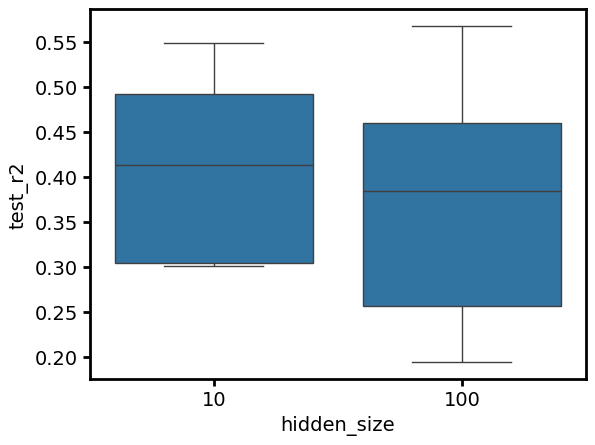

In [4]:
sns.boxplot(ndd_old[ndd_old['duration']==60],x='hidden_size',y='test_r2')

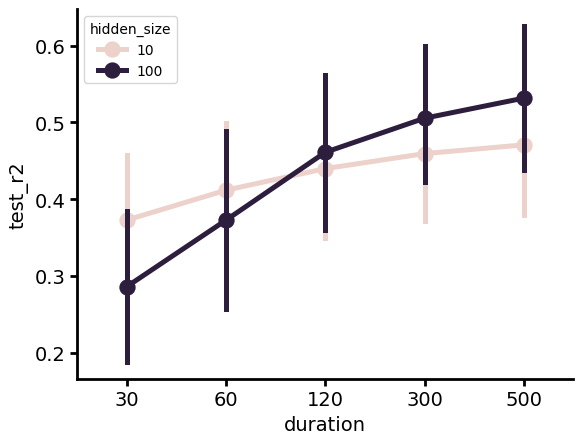

In [5]:
sns.pointplot(x='duration',hue='hidden_size',y='test_r2',data=ndd_old[ndd_old['forecast_length']==1],legend=True)
sns.despine()

## MINDD hyperparameter optimization

In [6]:
mindd_results = pd.read_csv(ospj(prodatapath, 'compiled_mindd_optimization_results.csv'))
mindd_results = mindd_results[(mindd_results['patient'] == 'HUP276')]
mindd_results = mindd_results[mindd_results.apply(lambda x: int(x.hidden_sizes.split(',')[0].replace(']','').replace('[','').split(' ')[0]) > x.n_channels*x.sequence_length*0.2,axis=1)]
top10 = mindd_results.nlargest(20, 'test_r2')
print(top10[['test_r2', 'train_r2','val_r2', 'hidden_sizes', 'weights','sequence_length']])

best_row = mindd_results.loc[mindd_results['test_r2'].idxmax()]
best_weights = best_row['weights']
print(f"Best test_r2: {best_row['test_r2']:.4f} with weights={best_weights}")

      test_r2  train_r2    val_r2   hidden_sizes     weights  sequence_length
838  0.846805  0.965526  0.903373  [23808, 3571]    (2, 0.3)              128
363  0.845000  0.958604  0.898688         [9523]      (0.8,)              128
350  0.841300  0.963947  0.899778   [9523, 3571]  (0.8, 0.3)              128
482  0.838377  0.955403  0.894399  [23808, 5952]    (2, 0.5)              128
146  0.836983  0.947585  0.888647         [5952]        (1,)               64
686  0.836541  0.951603  0.890698         [5952]      (0.5,)              128
274  0.826928  0.943451  0.882598        [11904]        (1,)              128
644  0.825952  0.941971  0.880302         [3571]      (0.3,)              128
411  0.824927  0.933344  0.875037         [4761]      (0.8,)               64
259  0.814732  0.938007  0.873368   [5952, 5952]  (0.5, 0.5)              128
816  0.814342  0.937076  0.872548   [5952, 9523]  (0.5, 0.8)              128
545  0.814245  0.933374  0.871234  [11904, 5952]    (1, 0.5)    

In [7]:
mindd_results = pd.read_csv(ospj(prodatapath, 'compiled_mindd_optimization_results.csv'))
mindd_results = mindd_results[(mindd_results['patient'] == 'HUP065')]
mindd_results = mindd_results[mindd_results.apply(lambda x: int(x.hidden_sizes.split(',')[0].replace(']','').replace('[','').split(' ')[0]) > x.n_channels*x.sequence_length*0.3,axis=1)]
top10 = mindd_results.nlargest(20, 'test_r2')
print(top10[['test_r2', 'train_r2','val_r2', 'hidden_sizes', 'weights','sequence_length']])

best_row = mindd_results.loc[mindd_results['test_r2'].idxmax()]
best_weights = best_row['weights']
print(f"Best test_r2: {best_row['test_r2']:.4f} with weights={best_weights}")

      test_r2  train_r2    val_r2  hidden_sizes     weights  sequence_length
534  0.858744  0.902651  0.894761   [2816, 422]    (2, 0.3)              128
788  0.840073  0.860177  0.874863   [2816, 704]    (2, 0.5)              128
844  0.831381  0.816321  0.866048  [1126, 2816]    (0.8, 2)              128
23   0.828822  0.808358  0.860316  [1126, 1126]  (0.8, 0.8)              128
20   0.828103  0.803983  0.860048  [1126, 1408]    (0.8, 1)              128
228  0.824571  0.816775  0.857192  [2816, 1126]    (2, 0.8)              128
746  0.817343  0.794082  0.846728   [1126, 422]  (0.8, 0.3)              128
715  0.816621  0.786109  0.847647        [2816]        (2,)              128
603  0.816537  0.782077  0.845812   [1126, 704]  (0.8, 0.5)              128
287  0.812146  0.776206  0.843029  [1408, 1126]    (1, 0.8)              128
208  0.809768  0.755488  0.836746        [1408]        (1,)              128
850  0.804837  0.760632  0.834478   [1408, 704]    (1, 0.5)              128

In [8]:
group_cols = ['sequence_length','weights']
ndd_data_avg = mindd_results.groupby(group_cols, dropna=False, as_index=False)[['train_r2','val_r2','test_r2']].mean()
best_params = []
max_r2 = ndd_data_avg['test_r2'].max()
best = ndd_data_avg[ndd_data_avg['test_r2'] == max_r2]
best_params.append(best)
if best_params:
    best_params_df = pd.concat(best_params, ignore_index=True)
    display(best_params_df.sort_values(['sequence_length']))
else:
    print("No best params found.")
    best_params_df = pd.DataFrame()

,sequence_length,weights,train_r2,val_r2,test_r2
0,128,"(2, 0.3)",0.902651,0.894761,0.858744


## NDD System Identification

In [9]:
# ndd_data = pd.read_csv(ospj(prodatapath,'res_series_list_deep.csv'))
# ndd_data['model'] = ndd_data['model'].apply(lambda x: x.split('.')[-1][:-2])

In [10]:
ndd_data = pd.read_csv(ospj(prodatapath,'compiled_ndd_optimization_results.csv'))
# ndd_data = ndd_data[ndd_data['patient']=='HUP065']
gin_data = ndd_data[ndd_data['model']=='GIN']
lin_data = ndd_data[ndd_data['model']=='LiNDDA']
min_data = ndd_data[ndd_data['model']=='MINDD']
lir_data = ndd_data[ndd_data.model=='LiRNDDA']

In [11]:
ndd_data.patient.nunique()

5

<Axes: xlabel='duration', ylabel='test_r2'>

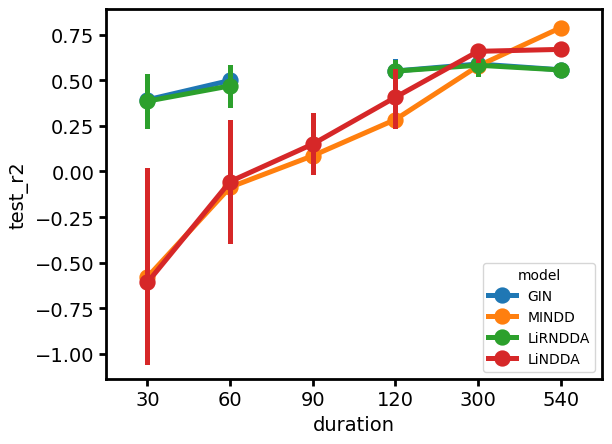

In [12]:
sns.pointplot(x='duration',hue='model',y='test_r2',data=ndd_data[ndd_data['sequence_length']==128])

In [13]:
group_cols = ['sequence_length','num_layers','num_stacks']
ndd_data_avg = gin_data[gin_data.duration == 120].groupby(group_cols, dropna=False, as_index=False)[['train_r2','val_r2','test_r2']].mean()
best_params = []
max_r2 = ndd_data_avg['test_r2'].max()
best = ndd_data_avg[ndd_data_avg['test_r2'] == max_r2]
best_params.append(best)
if best_params:
    best_params_df = pd.concat(best_params, ignore_index=True)
    display(best_params_df.sort_values(['sequence_length']))
else:
    print("No best params found.")
    best_params_df = pd.DataFrame()

,sequence_length,num_layers,num_stacks,train_r2,val_r2,test_r2
0,32,1.0,1.0,0.455521,0.53808,0.574985


<Axes: xlabel='sequence_length', ylabel='test_r2'>

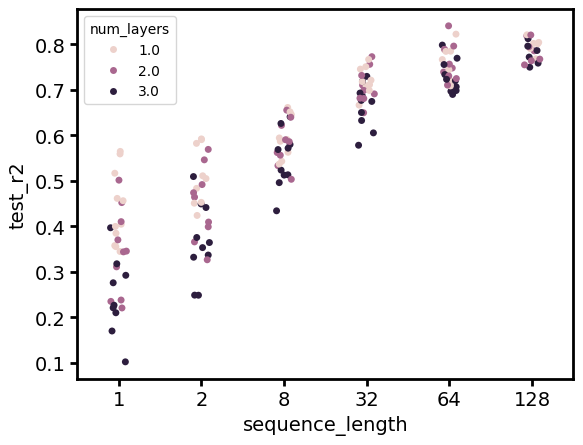

In [14]:
sns.stripplot(x='sequence_length',y='test_r2',hue='num_layers',data=min_data[min_data['duration']==540])

<Axes: xlabel='sequence_length', ylabel='train_s'>

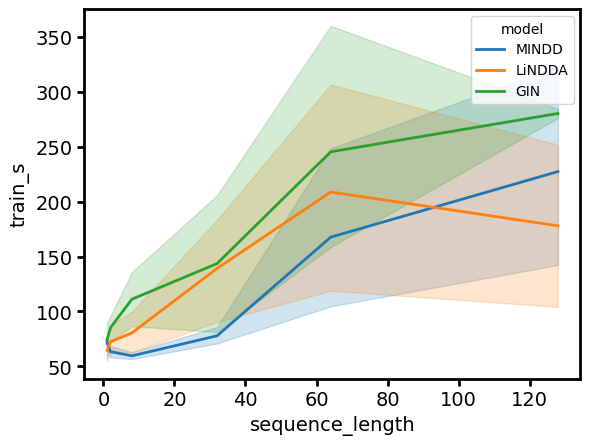

In [15]:
sns.lineplot(x='sequence_length',hue='model',y='train_s',data=ndd_data[(ndd_data['duration']==540)&(ndd_data.model != 'LiRNDDA')])

<Axes: xlabel='sequence_length', ylabel='test_r2'>

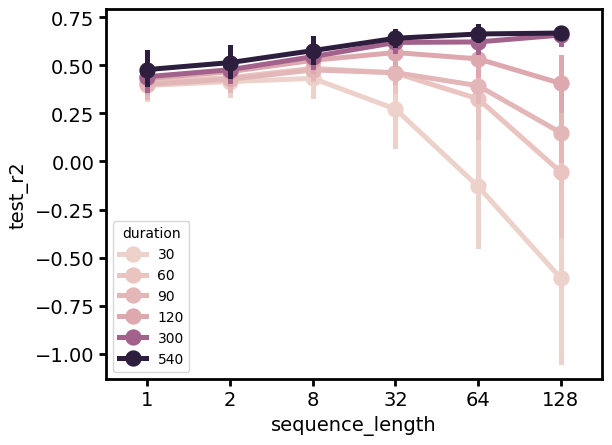

In [16]:
sns.pointplot(lin_data,x='sequence_length',hue='duration',y='test_r2')

(0.0, 1.0)

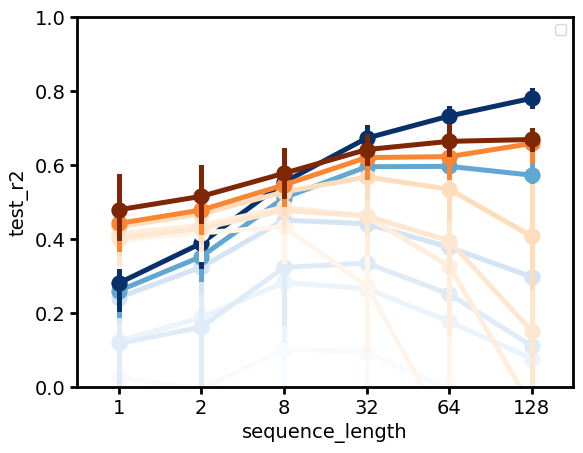

In [17]:
sns.pointplot(min_data[(min_data['param_scale']==1)],x='sequence_length',y='test_r2',hue='duration',palette='Blues')
sns.pointplot(lin_data,x='sequence_length',y='test_r2',hue='duration',palette='Oranges')
plt.legend([])
plt.ylim(0,1)

In [18]:
group_cols = ['model','duration','sequence_length','num_layers','param_scale','num_stacks','forecast_length']
ndd_data_avg = ndd_data.groupby(group_cols, dropna=False, as_index=False)[['train_r2','val_r2','test_r2']].mean()
best_params = []
for model in ndd_data_avg['model'].unique():
    for duration in ndd_data_avg['duration'].unique():
        subset = ndd_data_avg[(ndd_data_avg['model'] == model) & (ndd_data_avg['duration'] == duration)]
        if subset.empty: continue
        max_r2 = subset['test_r2'].max()
        best = subset[subset['test_r2'] == max_r2]
        best_params.append(best)
if best_params:
    best_params_df = pd.concat(best_params, ignore_index=True)
    display(best_params_df.sort_values(['model','duration','sequence_length']))
else:
    print("No best params found.")
    best_params_df = pd.DataFrame()


,model,duration,sequence_length,num_layers,param_scale,num_stacks,forecast_length,train_r2,val_r2,test_r2
0,GIN,30,64,1.0,NaN,1.0,1,0.378659,0.394394,0.409219
1,GIN,60,32,1.0,NaN,1.0,1,0.434224,0.462267,0.507847
2,GIN,120,32,1.0,NaN,1.0,1,0.455521,0.538080,0.574985
3,GIN,300,128,1.0,NaN,1.0,1,0.469911,0.551114,0.588645
4,GIN,540,32,1.0,NaN,1.0,1,0.471488,0.606583,0.608054
5,LiNDDA,30,8,NaN,NaN,NaN,1,0.434550,0.504924,0.432667
6,LiNDDA,60,8,NaN,NaN,NaN,1,0.431026,0.511783,0.484901
10,LiNDDA,90,8,NaN,NaN,NaN,1,0.425589,0.504898,0.476701
7,LiNDDA,120,32,NaN,NaN,NaN,1,0.527712,0.622853,0.567271
8,LiNDDA,300,128,NaN,NaN,NaN,1,0.630197,0.677594,0.657976


<Axes: xlabel='sequence_length', ylabel='test_r2'>

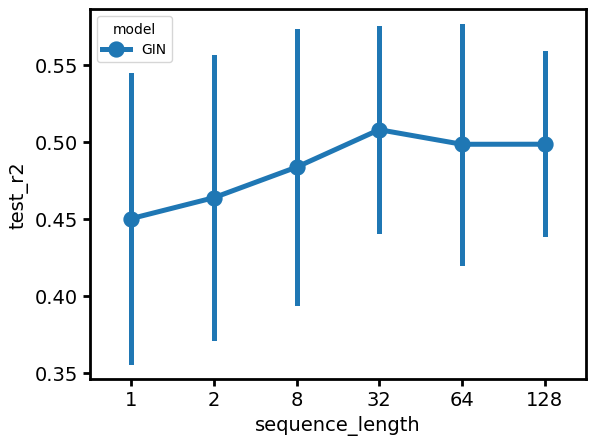

In [19]:
sns.pointplot(x='sequence_length',hue='model',y='test_r2',data=gin_data[(gin_data['duration']==60)])

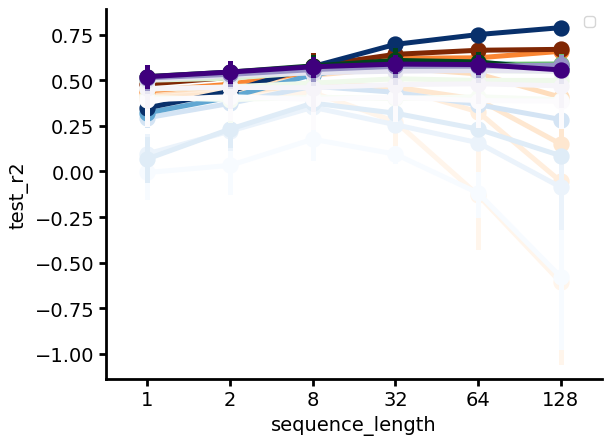

In [20]:
sns.pointplot(x='sequence_length',hue='duration',y='test_r2',data=lin_data[lin_data['forecast_length']==1],palette='Oranges')
sns.pointplot(x='sequence_length',hue='duration',y='test_r2',data=min_data[min_data['forecast_length']==1],palette='Blues')
sns.pointplot(x='sequence_length',hue='duration',y='test_r2',data=gin_data[gin_data['forecast_length']==1],palette='Greens')
sns.pointplot(x='sequence_length',hue='duration',y='test_r2',data=lir_data[lir_data['forecast_length']==1],palette='Purples')
plt.legend([])
sns.despine()

<Axes: xlabel='model', ylabel='train_s'>

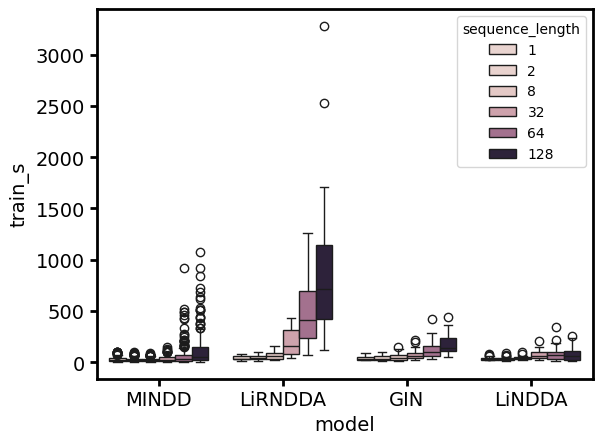

In [21]:
sns.boxplot(x='model',hue='sequence_length',y='train_s',data=ndd_data)

## Validation performance

In [22]:
shallow_data = pd.read_csv(ospj(prodatapath, "benchmark_model_validation_results.csv"))
shallow_melted = pd.melt(shallow_data, id_vars=['model'], value_vars=['auc','iou_f1','iou_phi','iou_sensitivity','iou_specificity','iou_precision','iou_recall','f1_f1','f1_phi','f1_sensitivity','f1_specificity','f1_precision','f1_recall'], var_name='metric', value_name='value')

In [23]:
shallow_data.onset.nunique()

1037

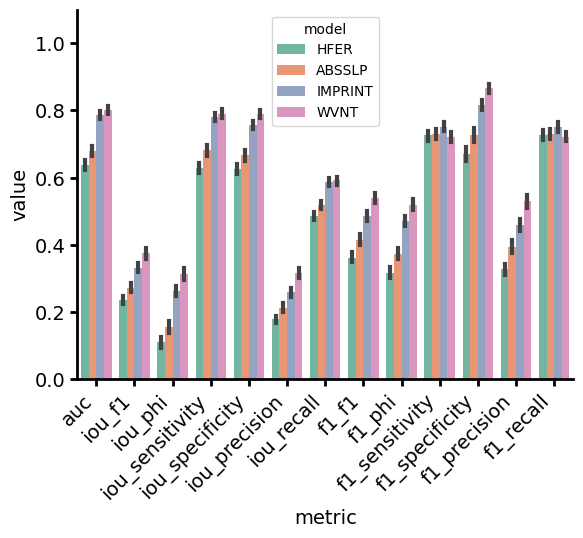

In [24]:
# sns.barplot(x='metric',y='value',hue='model',data=shallow_melted,palette=['purple','blue','green','red'],hue_order=['HFER','ABSSLP','IMPRINT','WVNT'])
sns.barplot(x='metric',y='value',hue='model',data=shallow_melted,palette='Set2',hue_order=['HFER','ABSSLP','IMPRINT','WVNT'])

# sns.stripplot(x='metric',y='value',hue='model',data=shallow_melted, dodge=True, jitter=True,alpha=0.1,color='gray',size=3,legend=False)
plt.ylim([0,1.1])
plt.xticks(rotation=45,ha='right')
sns.despine()

In [25]:
# sns.barplot(x='model',y='threshold',data=shallow_data,palette=['blue','green','red'])
# sns.stripplot(x='model',y='threshold',data=shallow_data, dodge=True, jitter=True,alpha=0.1,color='gray',size=3)
# sns.despine()
iou_benchmark_thresholds = shallow_data.groupby(['model','patient']).agg({'iou_threshold':'mean'}).reset_index().groupby('model').agg({'iou_threshold':'mean'}).reset_index()
f1_benchmark_thresholds = shallow_data.groupby(['model','patient']).agg({'f1_threshold':'mean'}).reset_index().groupby('model').agg({'f1_threshold':'mean'}).reset_index()

print(iou_benchmark_thresholds)
print(f1_benchmark_thresholds)

     model  iou_threshold
0   ABSSLP     266.747357
1     HFER      45.879924
2  IMPRINT      14.569977
3     WVNT       0.398446
     model  f1_threshold
0   ABSSLP    286.440674
1     HFER     49.215331
2  IMPRINT     17.580394
3     WVNT      0.466573


In [26]:
shallow_data[(shallow_data.patient == 'HUP225') & (shallow_data.model == 'WVNT')]

,patient,onset,split,stim,model,auc,iou_threshold,iou_f1,iou_phi,iou_sensitivity,iou_specificity,iou_precision,iou_recall,f1_threshold,f1_f1,f1_phi,f1_sensitivity,f1_specificity,f1_precision,f1_recall
2918,HUP225,403854,1,0,WVNT,0.363399,0.081024,0.060000,-0.102685,0.428571,0.335766,0.032258,0.428571,0.118853,0.092308,0.011888,0.428571,0.598540,0.051724,0.428571
2922,HUP225,604806,1,0,WVNT,0.339860,0.076513,0.034483,-0.151142,0.400000,0.230769,0.018018,0.400000,0.072021,0.061538,-0.023017,0.800000,0.153846,0.032000,0.800000
2926,HUP225,598273,1,0,WVNT,0.154348,0.073150,0.016807,-0.282717,0.200000,0.173913,0.008772,0.200000,0.073061,0.033058,-0.199992,0.400000,0.173913,0.017241,0.400000
2930,HUP225,311037,1,0,WVNT,0.391608,0.071923,0.021739,-0.147334,0.400000,0.398601,0.011494,0.200000,0.375541,0.285714,0.302019,0.200000,0.993007,0.500000,0.200000
2934,HUP225,309947,1,0,WVNT,0.685897,0.105359,0.137931,0.136517,0.666667,0.657343,0.076923,0.666667,0.155490,0.170213,0.179565,0.666667,0.741259,0.097561,0.666667
2938,HUP225,304819,1,0,WVNT,0.497868,0.183383,0.088235,-0.001870,0.428571,0.559701,0.049180,0.428571,0.643921,0.200000,0.192566,0.142857,0.985075,0.333333,0.142857
2942,HUP225,312474,1,0,WVNT,0.472906,0.124552,0.058252,-0.092468,0.428571,0.351724,0.031250,0.428571,0.852981,0.444444,0.525538,0.285714,1.000000,1.000000,0.285714


<Axes: ylabel='iou_threshold'>

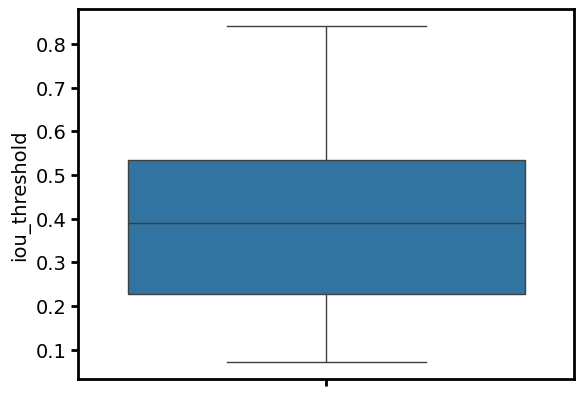

In [27]:
sns.boxplot(shallow_data[shallow_data.model == 'WVNT'].groupby(['model','patient']).agg({'iou_threshold':'mean'}).reset_index()['iou_threshold'])

In [28]:
f1_benchmark_thresholds.to_csv(ospj(prodatapath,'benchmark_val_thresholds_f1.csv'))
iou_benchmark_thresholds.to_csv(ospj(prodatapath,'benchmark_val_thresholds_iou.csv'))

## Generalized Validation performance

In [29]:
val_data = pd.read_csv(ospj(prodatapath, "benchmark_val_analysis_results_f1.csv"))


In [30]:
val_data.onset.nunique()

1030

In [31]:
val_data_onset = val_data.melt(id_vars=['patient','model'], value_vars=['sensitivity','specificity','f1','phi'], var_name='metric', value_name='value')
val_data_spread = val_data.melt(id_vars=['patient','model'], value_vars=['med_soz_spread_rank_pct','avg_soz_spread_rank_pct'], var_name='metric', value_name='value')
val_data_latency = val_data.melt(id_vars=['patient','model'], value_vars=['med_soz_recruitment_latency','avg_soz_recruitment_latency'], var_name='metric', value_name='value')

/tmp/ipykernel_37417/4198091649.py:2: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:gray'` for the same effect.

  sns.stripplot(x='metric',y='value',hue='model',data=val_data_onset,color='gray',jitter=True,alpha=0.1,legend=False,size=2,dodge=True)


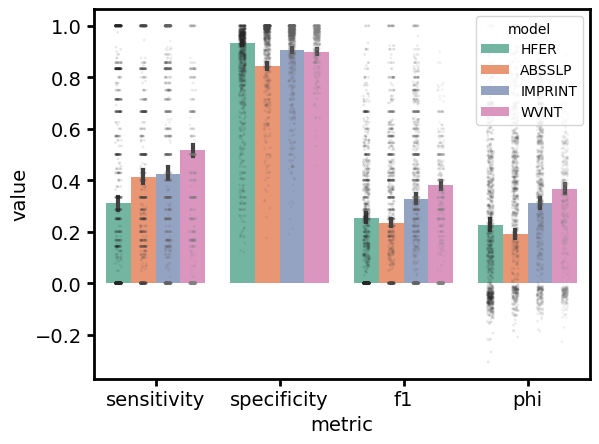

/tmp/ipykernel_37417/4198091649.py:6: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:gray'` for the same effect.

  sns.stripplot(x='metric',y='value',hue='model',data=val_data_spread,color='gray',jitter=True,alpha=0.1,legend=False,size=2,dodge=True)


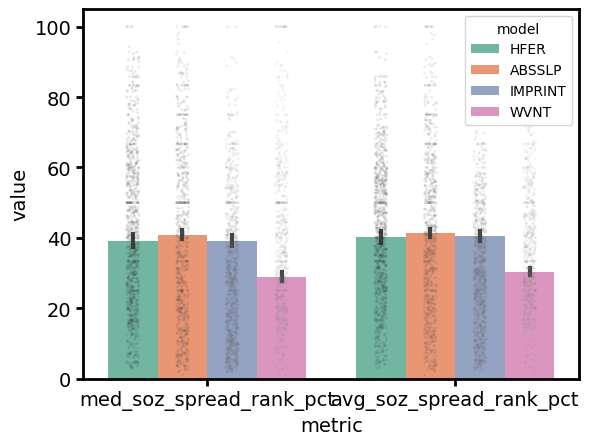

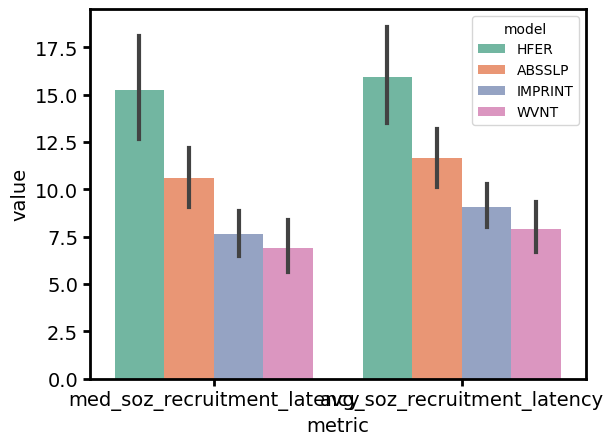

In [32]:
sns.barplot(x='metric',y='value',hue='model',data=val_data_onset,palette='Set2',hue_order=['HFER','ABSSLP','IMPRINT','WVNT'])
sns.stripplot(x='metric',y='value',hue='model',data=val_data_onset,color='gray',jitter=True,alpha=0.1,legend=False,size=2,dodge=True)
plt.show()

sns.barplot(x='metric',y='value',hue='model',data=val_data_spread,palette='Set2',hue_order=['HFER','ABSSLP','IMPRINT','WVNT'])
sns.stripplot(x='metric',y='value',hue='model',data=val_data_spread,color='gray',jitter=True,alpha=0.1,legend=False,size=2,dodge=True)
plt.show()

sns.barplot(x='metric',y='value',hue='model',data=val_data_latency,palette='Set2',hue_order=['HFER','ABSSLP','IMPRINT','WVNT'])
# sns.stripplot(x='metric',y='value',hue='model',data=val_data_latency,color='gray',jitter=True,alpha=0.1,legend=False,size=2,dodge=True)
plt.show()

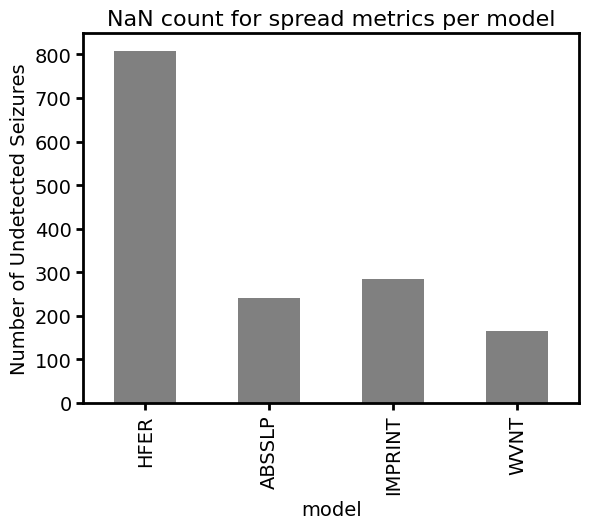

In [33]:
spread_nan_counts = val_data_spread[val_data_spread['value'].isna()].groupby('model').size()
spread_nan_counts = spread_nan_counts.reindex(['HFER','ABSSLP','IMPRINT','WVNT']).fillna(0)
spread_nan_counts.plot(kind='bar',color='gray')
plt.ylabel('Number of Undetected Seizures')
plt.title('NaN count for spread metrics per model')
plt.show()


## NDD performance

Initial rows: 36954

Metadata duplicates on 'onset': 6
Metadata duplicates on ['patient','onset']: 0
After first merge: 36954 rows

Total duplicate rows: 162

Patients/seizures with duplicate rows:
Total unique patient/onset combos with duplicates: 9


,patient,onset
19449,HUP097,133801
19593,HUP097,220200
21060,HUP110,148255
25308,HUP159,385739
29880,HUP206,109831
35010,HUP254,407520
35019,HUP254,424021
34974,HUP254,491963
34983,HUP254,509785



Sample of duplicate rows:


,patient,onset,split,model,sequence,forecast,auc,iou_threshold,iou_f1,iou_phi,...,iou_precision,iou_recall,f1_threshold,f1_f1,f1_phi,f1_sensitivity,f1_specificity,f1_precision,f1_recall,stim
19449,HUP097,133801,0,LiNDDA_mse,2,1,0.405844,0.492955,0.178571,-0.061363,...,0.113636,0.416667,0.332815,0.240000,0.042083,1.000000,0.012987,0.136364,1.000000,0
19452,HUP097,133801,0,LiNDDA_mse,4,1,0.390693,0.484625,0.175439,-0.070235,...,0.111111,0.416667,0.329019,0.240000,0.042083,1.000000,0.012987,0.136364,1.000000,0
19455,HUP097,133801,0,LiNDDA_mse,8,1,0.396104,0.475914,0.175439,-0.070235,...,0.111111,0.416667,0.320321,0.240000,0.042083,1.000000,0.012987,0.136364,1.000000,0
19458,HUP097,133801,0,LiNDDA_mse,2,1,0.405844,0.492955,0.178571,-0.061363,...,0.113636,0.416667,0.332815,0.240000,0.042083,1.000000,0.012987,0.136364,1.000000,0
19461,HUP097,133801,0,LiNDDA_mse,4,1,0.390693,0.484625,0.175439,-0.070235,...,0.111111,0.416667,0.329019,0.240000,0.042083,1.000000,0.012987,0.136364,1.000000,0
19464,HUP097,133801,0,LiNDDA_mse,8,1,0.396104,0.475914,0.175439,-0.070235,...,0.111111,0.416667,0.320321,0.240000,0.042083,1.000000,0.012987,0.136364,1.000000,0
19450,HUP097,133801,0,LiNDDA_mse_z,2,1,0.502165,0.684844,0.153846,-0.143849,...,0.094340,0.416667,1.600412,0.380952,0.304053,0.333333,0.935065,0.444444,0.333333,0
19453,HUP097,133801,0,LiNDDA_mse_z,4,1,0.515152,0.760747,0.178571,-0.061363,...,0.113636,0.416667,1.662227,0.380952,0.304053,0.333333,0.935065,0.444444,0.333333,0
19456,HUP097,133801,0,LiNDDA_mse_z,8,1,0.504329,0.782070,0.181818,-0.052518,...,0.116279,0.416667,1.627765,0.363636,0.276225,0.333333,0.922078,0.400000,0.333333,0
19459,HUP097,133801,0,LiNDDA_mse_z,2,1,0.502165,0.684844,0.153846,-0.143849,...,0.094340,0.416667,1.600412,0.380952,0.304053,0.333333,0.935065,0.444444,0.333333,0



Columns that vary in duplicate groups:

After deduplication: 36873 rows


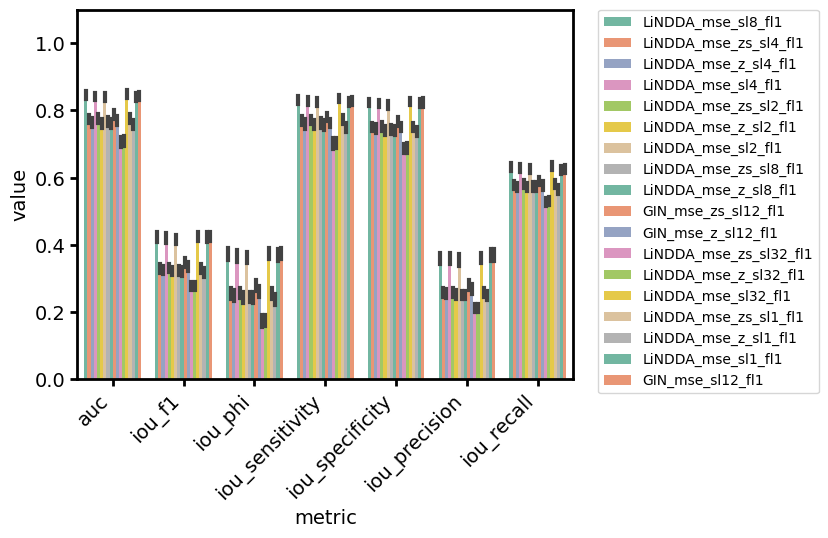

In [51]:
# ndd_data = pd.read_csv(ospj(prodatapath, 'ndd_model_validation_results.csv'))
# ndd_data_latter = pd.read_csv(ospj(prodatapath, 'ndd_model_validation_results_latter.csv'))
# ndd_data_lat_server = pd.read_csv(ospj(prodatapath, 'ndd_model_validation_results_latter_server.csv'))

# ndd_data = pd.concat([ndd_data,ndd_data_latter,ndd_data_lat_server])
# ndd_data_32 = pd.read_csv(ospj(prodatapath, 'ndd_model_validation_results_seq32.csv'))
# ndd_data_32s = pd.read_csv(ospj(prodatapath, 'ndd_model_validation_results_seq32_server.csv'))
# ndd_data = pd.concat([ndd_data,ndd_data_32,ndd_data_32s])
# ndd_data = pd.read_csv(ospj(prodatapath,'ndd_model_validation_results_100.csv'))
# mindd_data = pd.read_csv(ospj(prodatapath,f"mindd_model_validation_results_100.csv"))
# ndd_data = pd.concat([ndd_data,mindd_data])
ndd_data = pd.read_csv(ospj(prodatapath,'ndd_model_validation_results_v2.csv'))
ndd_data_temp = pd.read_csv(ospj(prodatapath,'ndd_model_validation_results_v2_linddaseq.csv'))
ndd_data = pd.concat([ndd_data,ndd_data_temp])
print(f"Initial rows: {len(ndd_data)}")

metadata = pd.read_csv(ospj(metapath,'metadata_v6_BIDS.csv'))
metadata['patient'] = metadata['Patient']
metadata['stim'] = metadata['stim'].fillna(0)
metadata['onset'] = metadata['onset'].astype(int)

print(f"\nMetadata duplicates on 'onset': {metadata['onset'].duplicated().sum()}")
print(f"Metadata duplicates on ['patient','onset']: {metadata[['patient','onset']].duplicated().sum()}")

# First merge
ndd_data = ndd_data.merge(metadata[['patient', 'onset', 'stim']], on=['patient', 'onset'], how='left')
print(f"After first merge: {len(ndd_data)} rows")

# Check for duplicates (excluding stim column)
key_cols = [col for col in ndd_data.columns if col != 'stim']
duplicates_mask = ndd_data.duplicated(subset=key_cols, keep=False)
print(f"\nTotal duplicate rows: {duplicates_mask.sum()}")

if duplicates_mask.sum() > 0:
    print("\nPatients/seizures with duplicate rows:")
    dup_patients_onsets = ndd_data[duplicates_mask][['patient','onset']].drop_duplicates().sort_values(['patient','onset'])
    print(f"Total unique patient/onset combos with duplicates: {len(dup_patients_onsets)}")
    display(dup_patients_onsets)
    
    print("\nSample of duplicate rows:")
    display(ndd_data[duplicates_mask].sort_values(['patient','onset','model']).head(20))
    
    # Show what columns vary in duplicates
    print("\nColumns that vary in duplicate groups:")
    dup_subset = ndd_data[duplicates_mask]
    for col in ndd_data.columns:
        n_unique_per_group = dup_subset.groupby(key_cols)[col].nunique()
        if (n_unique_per_group > 1).any():
            print(f"  {col}: varies")

# Handle duplicates by taking max stim value
ndd_data = ndd_data.sort_values('stim', ascending=False).drop_duplicates(subset=key_cols, keep='first')
print(f"\nAfter deduplication: {len(ndd_data)} rows")

ndd_data = ndd_data[ndd_data.split == 1]
ndd_data.loc[ndd_data.model.apply(lambda x: 'onset' in x),'model'] = ndd_data.loc[ndd_data.model.apply(lambda x: 'onset' in x),'model'].apply(lambda x: x.replace('onset_',''))
ndd_data['model'] = ndd_data['model'].astype(str) + '_sl' + ndd_data['sequence'].astype(str) + '_fl' + ndd_data['forecast'].astype(str)
ndd_data = ndd_data[ndd_data.model.apply(lambda x: True)] # ('_mse_s' in x) ('prob_s' in x) and ('fl16' not in x) ('_mse_s' in x) and  ('LiN' in x) and ('LiN' not in x) andand ('_mse_s' in x))
value_vars = ['auc','iou_f1','iou_phi','iou_sensitivity','iou_specificity','iou_precision','iou_recall']
ndd_melted = pd.melt(ndd_data, id_vars=['model'], value_vars=value_vars, var_name='metric', value_name='value')
sns.barplot(x='metric',y='value',hue='model',data=ndd_melted,palette='Set2',estimator=np.mean)
plt.ylim([0,1.1])
plt.xticks(rotation=45,ha='right')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.show()

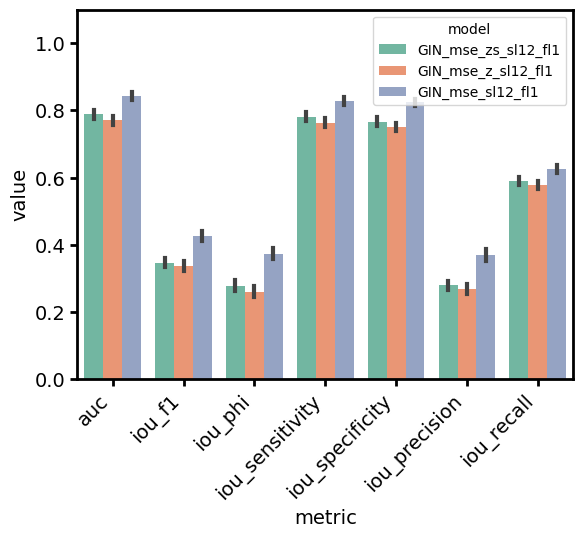

In [52]:
metric_data = ndd_melted[ndd_melted.model.apply(lambda x: ('GIN' in x) and ('fl16' not in x) and ('sl12' in x))] #  ('prob_s' in x) and ('fl16' not in x) ('_mse_s' in x) and  ('LiN' in x) and ('LiN' not in x) andand ('_mse_s' in x))
sns.barplot(x='metric',y='value',hue='model',data=metric_data,palette='Set2')
plt.ylim([0,1.1])
plt.xticks(rotation=45,ha='right')
# plt.legend(loc='upper left')
plt.show()

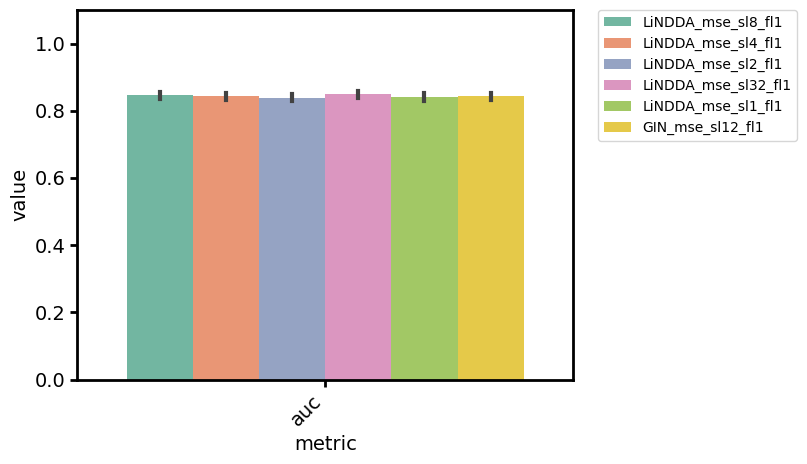

In [53]:
metric_data = ndd_melted[ndd_melted.model.apply(lambda x: (('GIN' in x) or ('LiN' in x) or ('MINDD' in x)) and ('fl16' not in x) and (('_mse_s' in x) or ('_prob' in x)))]
metric_data = metric_data[metric_data.metric == 'auc'] # and ('sl12' in x) ('prob_s' in x) and ('fl16' not in x)  and  ('LiN' in x) and ('LiN' not in x) andand ('_mse_s' in x))
sns.barplot(x='metric',y='value',hue='model',data=metric_data,palette='Set2')
plt.ylim([0,1.1])
plt.xticks(rotation=45,ha='right')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.show()

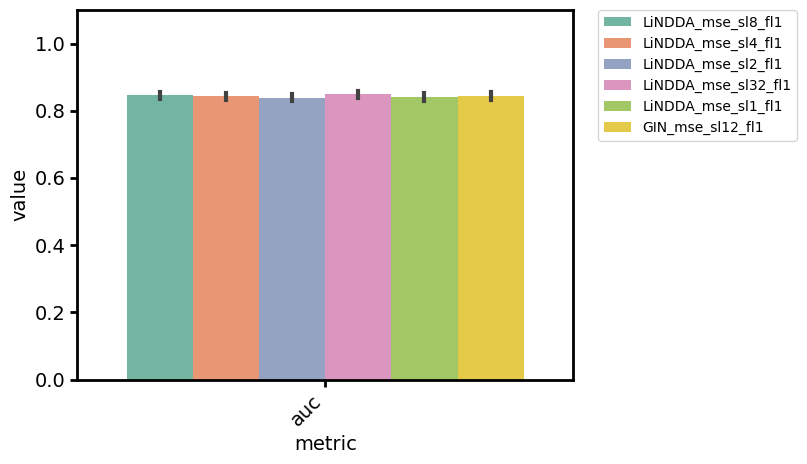

In [54]:
metric_data = ndd_melted[ndd_melted.model.apply(lambda x: (('GIN' in x) or ('LiN' in x) or ('MINDD' in x)) and (('_mse_s' in x)))]
metric_data = metric_data[metric_data.metric == 'auc'] # and ('sl12' in x) ('prob_s' in x) and ('fl16' not in x)  and  ('LiN' in x) and ('LiN' not in x) andand ('_mse_s' in x))
sns.barplot(x='metric',y='value',hue='model',data=metric_data,palette='Set2')
plt.ylim([0,1.1])
plt.xticks(rotation=45,ha='right')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.show()

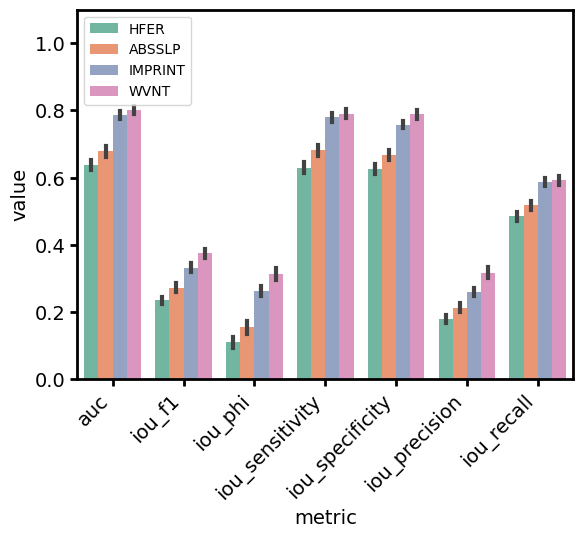

In [55]:
benchmark_data = pd.read_csv(ospj(prodatapath, 'benchmark_model_validation_results.csv'))
benchmark_data = benchmark_data[benchmark_data.onset.isin(ndd_data.onset)]
benchmark_melted = benchmark_data.melt(id_vars=['model'], value_vars=value_vars, var_name='metric', value_name='value')

sns.barplot(x='metric',y='value',hue='model',data=benchmark_melted,palette='Set2',hue_order=['HFER','ABSSLP','IMPRINT','WVNT'])
plt.ylim([0,1.1])
plt.xticks(rotation=45,ha='right')
plt.legend(loc='upper left')
plt.show()

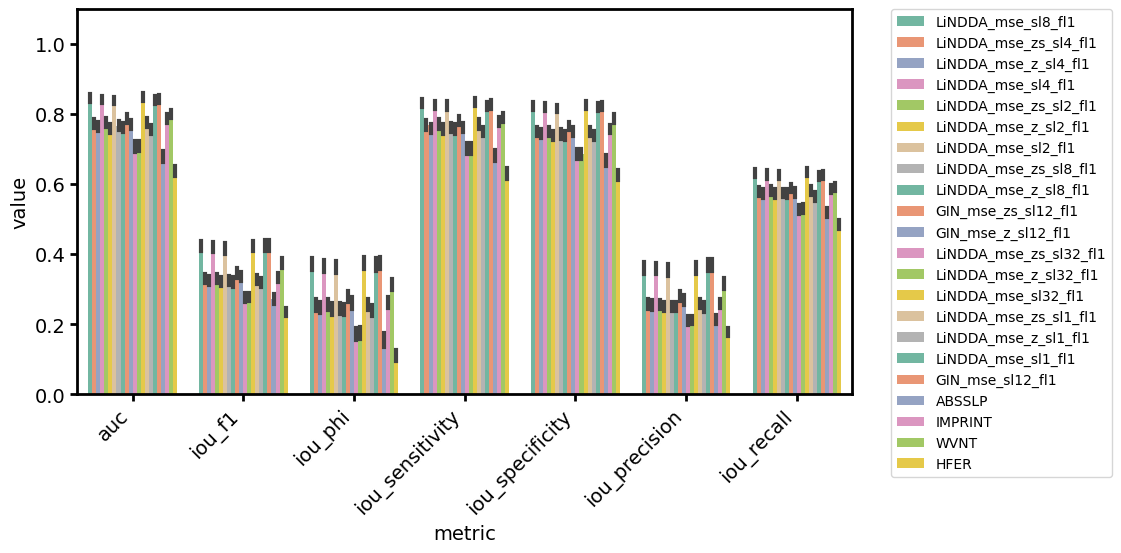

In [56]:
all_data = pd.concat([ndd_melted,benchmark_melted],axis=0).reset_index(drop=True)
fig,ax = plt.subplots(figsize=(10,5))
sns.barplot(x='metric',y='value',hue='model',data=all_data,palette='Set2',estimator=np.mean)
plt.ylim([0,1.1])
plt.xticks(rotation=45,ha='right')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

plt.show()

In [57]:
# Find the model with the highest average performance for each metric
best_models_per_metric = all_data.groupby(['metric', 'model'])['value'].median().reset_index()
top3_models = best_models_per_metric.groupby('metric').apply(lambda x: x.nlargest(5, 'value')).reset_index(drop=True)
print("Top 3 models for each metric:")
print(top3_models)

Top 3 models for each metric:
             metric                model     value
0               auc     GIN_mse_sl12_fl1  0.924603
1               auc  LiNDDA_mse_sl32_fl1  0.924603
2               auc   LiNDDA_mse_sl4_fl1  0.924603
3               auc   LiNDDA_mse_sl8_fl1  0.924603
4               auc   LiNDDA_mse_sl1_fl1  0.923611
5            iou_f1     GIN_mse_sl12_fl1  0.428571
6            iou_f1  LiNDDA_mse_sl32_fl1  0.428571
7            iou_f1   LiNDDA_mse_sl8_fl1  0.421053
8            iou_f1   LiNDDA_mse_sl1_fl1  0.421053
9            iou_f1   LiNDDA_mse_sl4_fl1  0.421053
10          iou_phi     GIN_mse_sl12_fl1  0.395285
11          iou_phi  LiNDDA_mse_sl32_fl1  0.395285
12          iou_phi   LiNDDA_mse_sl1_fl1  0.394887
13          iou_phi   LiNDDA_mse_sl8_fl1  0.393962
14          iou_phi   LiNDDA_mse_sl4_fl1  0.391640
15    iou_precision  LiNDDA_mse_sl32_fl1  0.307692
16    iou_precision     GIN_mse_sl12_fl1  0.305009
17    iou_precision   LiNDDA_mse_sl1_fl1  0.300000
1

In [58]:
iou_ndd_thresholds = ndd_data.groupby(['model','patient']).agg({'iou_threshold':'mean'}).reset_index().groupby('model').agg({'iou_threshold':'mean'}).reset_index()
f1_ndd_thresholds = ndd_data.groupby(['model','patient']).agg({'f1_threshold':'mean'}).reset_index().groupby('model').agg({'f1_threshold':'mean'}).reset_index()

print(iou_ndd_thresholds)
print(f1_ndd_thresholds)

                     model  iou_threshold
0         GIN_mse_sl12_fl1       0.914958
1       GIN_mse_z_sl12_fl1       6.005966
2      GIN_mse_zs_sl12_fl1       5.685621
3       LiNDDA_mse_sl1_fl1       0.903576
4       LiNDDA_mse_sl2_fl1       0.893323
5      LiNDDA_mse_sl32_fl1       0.956012
6       LiNDDA_mse_sl4_fl1       0.898515
7       LiNDDA_mse_sl8_fl1       0.913339
8     LiNDDA_mse_z_sl1_fl1       5.577631
9     LiNDDA_mse_z_sl2_fl1       6.345157
10   LiNDDA_mse_z_sl32_fl1      16.598701
11    LiNDDA_mse_z_sl4_fl1       7.219779
12    LiNDDA_mse_z_sl8_fl1       8.600745
13   LiNDDA_mse_zs_sl1_fl1       5.217807
14   LiNDDA_mse_zs_sl2_fl1       6.014717
15  LiNDDA_mse_zs_sl32_fl1      16.541118
16   LiNDDA_mse_zs_sl4_fl1       6.903768
17   LiNDDA_mse_zs_sl8_fl1       8.341225
                     model  f1_threshold
0         GIN_mse_sl12_fl1      0.952719
1       GIN_mse_z_sl12_fl1      6.568027
2      GIN_mse_zs_sl12_fl1      6.127939
3       LiNDDA_mse_sl1_fl1      0.9460

In [ ]:
# f1_ndd_thresholds.to_csv(ospj(prodatapath,'ndd_val_thresholds_f1_v2.csv'))
# iou_ndd_thresholds.to_csv(ospj(prodatapath,'ndd_val_thresholds_iou_v2.csv'))

## NDD generalization performance

In [ ]:
thresh_key = 'iou'
benchmark_val = pd.read_csv(ospj(prodatapath, f"benchmark_val_analysis_results_{thresh_key}.csv"))
ndd_val = pd.read_csv(ospj(prodatapath, f"ndd_spread_analysis_results_{thresh_key}_v2.csv"), on_bad_lines='warn')
ndd_val = ndd_val[(ndd_val.model.apply(lambda x: (('GIN' in x) or ('LiN' in x)) and (('_mse_s' in x)) and (('sl1' in x) or ('sl12' in x)) and ('fl16' not in x))) & (ndd_val.model_name.apply(lambda x: 'tau' not in x))]
mdl_map = {'LiNDDA_mse_sl1_fl1':'LiNDDA','GIN_mse_sl12_fl1':'NDD'}
ndd_val['model'] = ndd_val['model'].map(mdl_map)
benchmark_val = benchmark_val[benchmark_val.onset.isin(ndd_val.onset)]
all_val = pd.concat([benchmark_val,ndd_val])
na_list = ['f1','phi','sensitivity','specificity','precision','recall']
all_val[na_list] = all_val[na_list].fillna(0)
print(all_val.onset.nunique())
print(all_val.patient.nunique())
avg_seizures_per_patient = all_val.groupby('patient').onset.nunique()
print("Average seizures per patient:", avg_seizures_per_patient.mean())
print("Std seizures per patient:", avg_seizures_per_patient.std())
# all_val = ndd_val
all_val_melted = pd.melt(all_val, id_vars=['model'], value_vars=['auc','f1','phi','sensitivity','specificity','precision'], var_name='metric', value_name='value')

1017
107
Average seizures per patient: 9.523364485981308
Std seizures per patient: 17.03733181475012
model   patient
ABSSLP  HUP064    NaN
        HUP065    NaN
        HUP068    NaN
        HUP070    NaN
        HUP073    NaN
                   ..
WVNT    HUP267    NaN
        HUP273    NaN
        HUP274    NaN
        HUP275    NaN
        HUP284    NaN
Name: nsoz, Length: 635, dtype: float64


/tmp/ipykernel_56333/3018869270.py:16: RuntimeWarning: Mean of empty slice
  print(all_val.groupby(['model','patient'])['nsoz'].apply(lambda x: np.nanmean(x)))


In [57]:
ndd_val.groupby(['model','patient'],as_index=False)['nsoz'].apply(lambda x: np.nanmean(x)).groupby('model',as_index=False)['nsoz'].mean()

/tmp/ipykernel_56333/2785548357.py:1: RuntimeWarning: Mean of empty slice
  ndd_val.groupby(['model','patient'],as_index=False)['nsoz'].apply(lambda x: np.nanmean(x)).groupby('model',as_index=False)['nsoz'].mean()


,model,nsoz
0,LiNDDA,0.544057
1,NDD,0.535944


In [45]:
hue_order = ['HFER','ABSSLP','IMPRINT','WVNT','LiNDDA', 'NDD']
color_palette = ['#377eb8','#4daf4a','#984ea3','#e41a1c','#ff7f00','#a65628']
# color_palette = ['#f5ecdc', '#c4d5a7', '#7dbc95', '#469c9c', '#665b7f', '#4fc3e6', '#5673b6']
# color_palette = ['#ffe78e', '#b8db7d', '#60ccc8', '#379cac', '#38598c', '#2c2251', '#2d1737']
# color_palette = ['#fcfdbf', '#daea6f', '#a8c96a', '#74a268', '#447484', '#38598c', '#00202c']
# color_palette = ['#f6e8aa', '#b1e47d', '#57c899', '#4398b9', '#665b7f', '#423c76', '#372944']

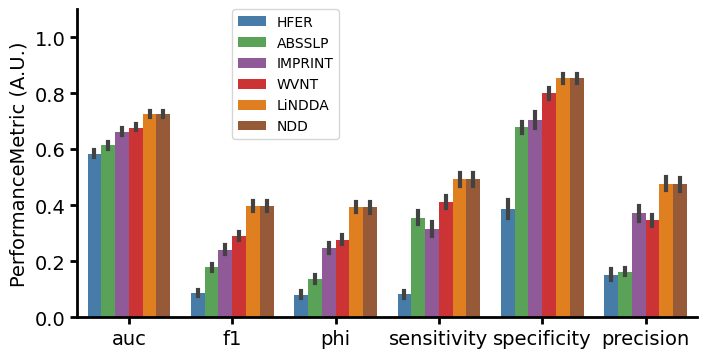

In [46]:
plt.figure(figsize=(8,4))
sns.barplot(x='metric',y='value',hue='model',data=all_val_melted,
estimator=np.mean,
palette=color_palette,
hue_order=hue_order,
gap=0.0
)

plt.legend(loc='upper left', bbox_to_anchor=(0.25, 1), borderaxespad=0.)
plt.ylim([0,1.1])
plt.xlabel('')
plt.ylabel('PerformanceMetric (A.U.)')
sns.despine()
plt.show()

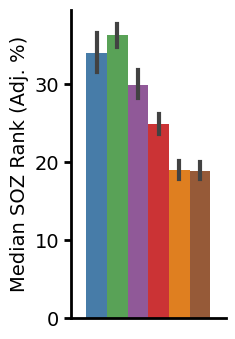

In [ ]:
spread_val_melted = pd.melt(all_val, id_vars=['model'], value_vars=['adj_med_soz_spread_rank_pct'], var_name='metric', value_name='value')
plt.figure(figsize=(2,4))
sns.barplot(x='metric',y='value',hue='model',data=spread_val_melted,
palette=color_palette,
hue_order=hue_order,
gap=0.0,
legend=False
)
# plt.legend(bbox_to_anchor=(0.795, 1), loc='upper left', borderaxespad=0.)
plt.xlabel('')
plt.xticks([])
plt.ylabel('Median SOZ Rank (Adj. %)')

sns.despine()

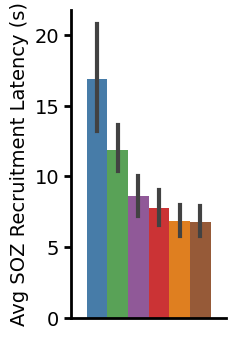

In [149]:
spread_val_melted = pd.melt(all_val, id_vars=['model'], value_vars=['avg_soz_recruitment_latency'], var_name='metric', value_name='value')

plt.figure(figsize=(2,4))
sns.barplot(x='metric',y='value',hue='model',data=spread_val_melted,
estimator=np.mean,
palette=color_palette,
hue_order=hue_order,
gap=0.0,
legend=False
)
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.ylabel('Avg SOZ Recruitment Latency (s)')
plt.xlabel('')
plt.xticks([])
sns.despine()
plt.show()

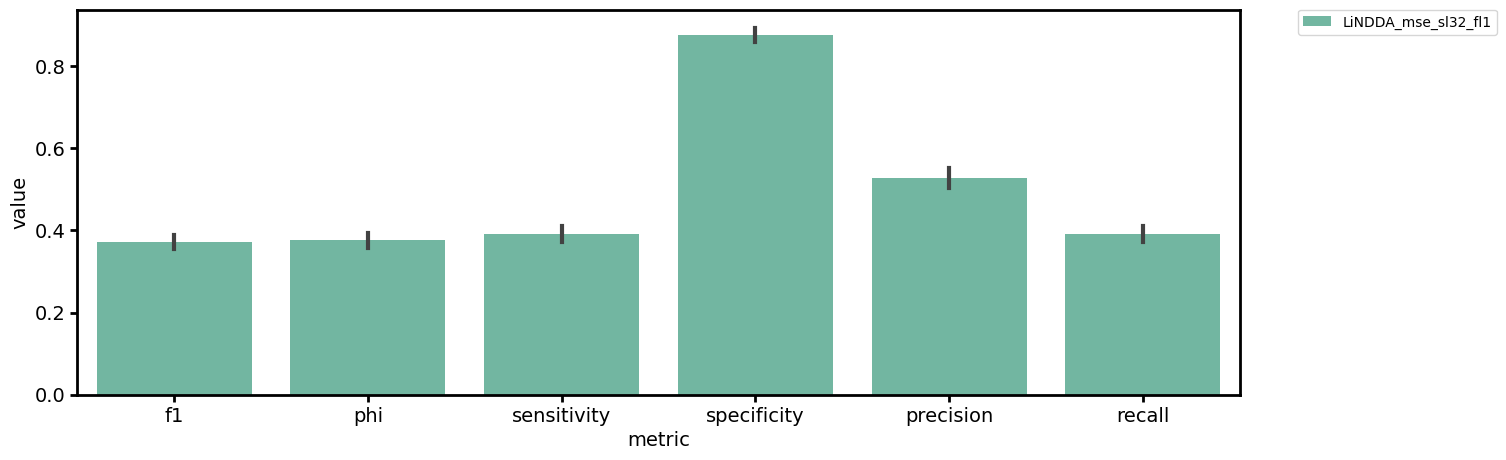

In [ ]:
metric_data = all_val_melted[all_val_melted.model.apply(lambda x: (('GIN' in x) or ('LiN' in x) or ('MINDD' in x)) and (('_mse_s' in x)) and ('sl' not in x))]
plt.figure(figsize=(15,5))
sns.barplot(x='metric',y='value',hue='model',data=metric_data,palette='Set2',estimator=np.mean)#,hue_order=['HFER','ABSSLP','IMPRINT','WVNT','LiNDDA_mse_sl1_fl1'],estimator=np.mean)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

In [74]:
# Find the model with the highest average performance for each metric
best_models_per_metric = all_val_melted.groupby(['metric', 'model'])['value'].mean().reset_index()
top3_models = best_models_per_metric.groupby('metric').apply(lambda x: x.nlargest(5, 'value')).reset_index(drop=True)
print("Top 3 models for each metric:")
print(top3_models)

Top 3 models for each metric:
         metric                model     value
0            f1   LiNDDA_mse_sl1_fl1  0.396136
1            f1     GIN_mse_sl12_fl1  0.395749
2            f1  LiNDDA_mse_sl32_fl1  0.371826
3            f1                 WVNT  0.294019
4            f1              IMPRINT  0.248994
5           phi   LiNDDA_mse_sl1_fl1  0.393058
6           phi     GIN_mse_sl12_fl1  0.392432
7           phi  LiNDDA_mse_sl32_fl1  0.375796
8           phi                 WVNT  0.281080
9           phi              IMPRINT  0.254755
10    precision  LiNDDA_mse_sl32_fl1  0.527897
11    precision   LiNDDA_mse_sl1_fl1  0.476301
12    precision     GIN_mse_sl12_fl1  0.474276
13    precision              IMPRINT  0.379540
14    precision                 WVNT  0.344094
15       recall     GIN_mse_sl12_fl1  0.494143
16       recall   LiNDDA_mse_sl1_fl1  0.492727
17       recall                 WVNT  0.417581
18       recall  LiNDDA_mse_sl32_fl1  0.391131
19       recall               

## Visualization

In [50]:
test_mat = pd.read_pickle(ospj(prodatapath,'sz_prob','HUP235','HUP235_task-ictal116938_mdl-LiNDDA_seq-1_mse_prob_forecast-1.pkl'))
prob_times = test_mat.pop('time')

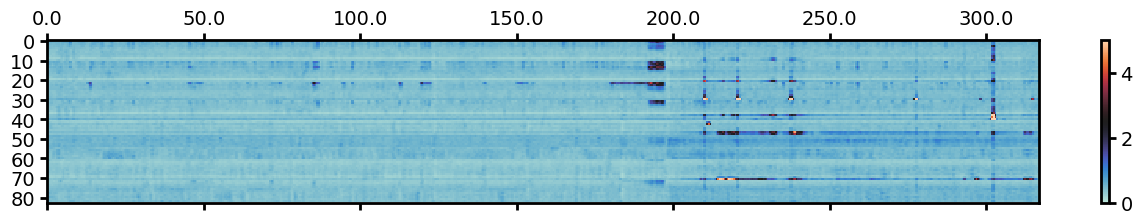

In [51]:
plt.matshow(test_mat.T,aspect='auto',cmap='icefire',
clim=(0,5)
)
plt.xticks(ticks=np.arange(0, len(prob_times), 100), labels=prob_times.to_numpy()[::100].round(0))
plt.colorbar()
plt.show()
